# In this notebook, we will provide a brief update to see how our portfolios did

In [1]:
import pandas as pd
import numpy as np
from stockdex import Ticker
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date
import yfinance as yf
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Save important dates
FED_CUT_DATE = date(2025, 9, 17)
TARRIF_DATE = date(2025, 10, 9)

## Portfolio #1. Portfolio created through graph's

In [3]:
p1 = pd.read_csv("sept-07-portfolio.csv")
p1_amt = p1[["Symbol", "n_shares"]]

display(p1)
print(); print()
display(p1_amt.head())

,Symbol,Monthly_Sharpe_Ratio,Annualized_Sharpe_Ratio,Group,Close,instrumentType,frac_inv,n_shares,invt_amount
0,GS,0.403390,1.397384,Cluster: 1,738.830017,EQUITY,0.041612,0.563220,416.124072
1,IWF,0.263001,0.911061,Cluster: 2,452.269989,ETF,0.027130,0.599869,271.302834
2,JPM,0.427168,1.479755,Cluster: 5,293.128510,EQUITY,0.044065,1.503276,440.653062
3,EWI,0.444357,1.539299,Cluster: 6,50.619999,ETF,0.045838,9.055405,458.384592
4,SGOL,0.568194,1.968283,Cluster: 8,34.660000,ETF,0.058613,16.910866,586.130597
5,RCL,0.491664,1.703176,Cluster: 12,353.529999,EQUITY,0.050719,1.434631,507.185015
6,SIVR,0.349293,1.209985,Cluster: 13,39.380001,ETF,0.036032,9.149794,360.318915
7,GEV,0.655345,2.270180,Cluster: 14,602.530029,EQUITY,0.067603,1.121989,676.032102
8,VMC,0.199745,0.691937,Cluster: 16,298.559998,EQUITY,0.020605,0.690148,206.050556
9,PWR,0.259033,0.897317,Cluster: 18,376.089996,EQUITY,0.026721,0.710495,267.210187


,Symbol,n_shares
0,GS,0.563220
1,IWF,0.599869
2,JPM,1.503276
3,EWI,9.055405
4,SGOL,16.910866


In [4]:
p1_tickers = p1.Symbol.tolist()

In [5]:
# Get data for investment time
inv_start = date(2025, 9, 8)
inv_end = date(2025, 10, 10)

p1_prices = pd.DataFrame()
start = time.time()
print("Loading...")

# Columns returned by .yahoo_api_price: timestamp, volume, close, open, high, low, currency, timezone, exchangeTimezoneName, exchangeName, instrumentType
for ticker in p1_tickers: 
    temp_tick = Ticker(ticker)
    security_df = temp_tick.yahoo_api_price(range='1y', dataGranularity='1d')
    security_df = security_df[["timestamp", "low", "high", "open", "close", "instrumentType"]]
    
    mask = (security_df["timestamp"].dt.date >= inv_start) & (security_df["timestamp"].dt.date <= inv_end)
    filtered_df = security_df[mask]
    
    # Use .loc[] to avoid SettingWithCopyWarning
    filtered_df.loc[:, "Symbol"] = ticker
    
    p1_prices = pd.concat([p1_prices, filtered_df])

end = time.time()
print("Loaded in ", end-start, " seconds")

Loading...
Loaded in  4.3975770473480225  seconds


In [6]:
p1_prices

,timestamp,low,high,open,close,instrumentType,Symbol
225,2025-09-08 13:30:00,733.570007,743.539978,739.419983,741.849976,EQUITY,GS
226,2025-09-09 13:30:00,738.539978,765.619995,740.130005,763.919983,EQUITY,GS
227,2025-09-10 13:30:00,761.630005,774.469971,761.859985,769.580017,EQUITY,GS
228,2025-09-11 13:30:00,771.349976,793.169983,772.000000,784.729980,EQUITY,GS
229,2025-09-12 13:30:00,776.260010,787.030029,783.500000,780.059998,EQUITY,GS
...,...,...,...,...,...,...,...
245,2025-10-06 13:30:00,315.089996,324.209991,322.410004,321.100006,EQUITY,RL
246,2025-10-07 13:30:00,317.859985,325.529999,322.869995,324.769989,EQUITY,RL
247,2025-10-08 13:30:00,321.429993,329.750000,325.420013,329.029999,EQUITY,RL
248,2025-10-09 13:30:00,321.899994,330.109985,329.149994,322.929993,EQUITY,RL


In [7]:
p1_prices["pct_change"] = p1_prices.groupby("Symbol")["close"].pct_change()
p1_prices["pct_change"]

225         NaN
226    0.029750
227    0.007409
228    0.019686
229   -0.005951
         ...   
245   -0.002206
246    0.011429
247    0.013117
248   -0.018539
249   -0.041836
Name: pct_change, Length: 675, dtype: float64

,Symbol,pct_change
16,NWS,-0.138063
18,RCL,-0.132285
1,CCL,-0.122624
23,UAL,-0.102997
6,FOXA,-0.083387
12,JBL,-0.072573
2,EMR,-0.050629
4,EWH,-0.034579
20,ROK,-0.031683
26,XLI,-0.009057


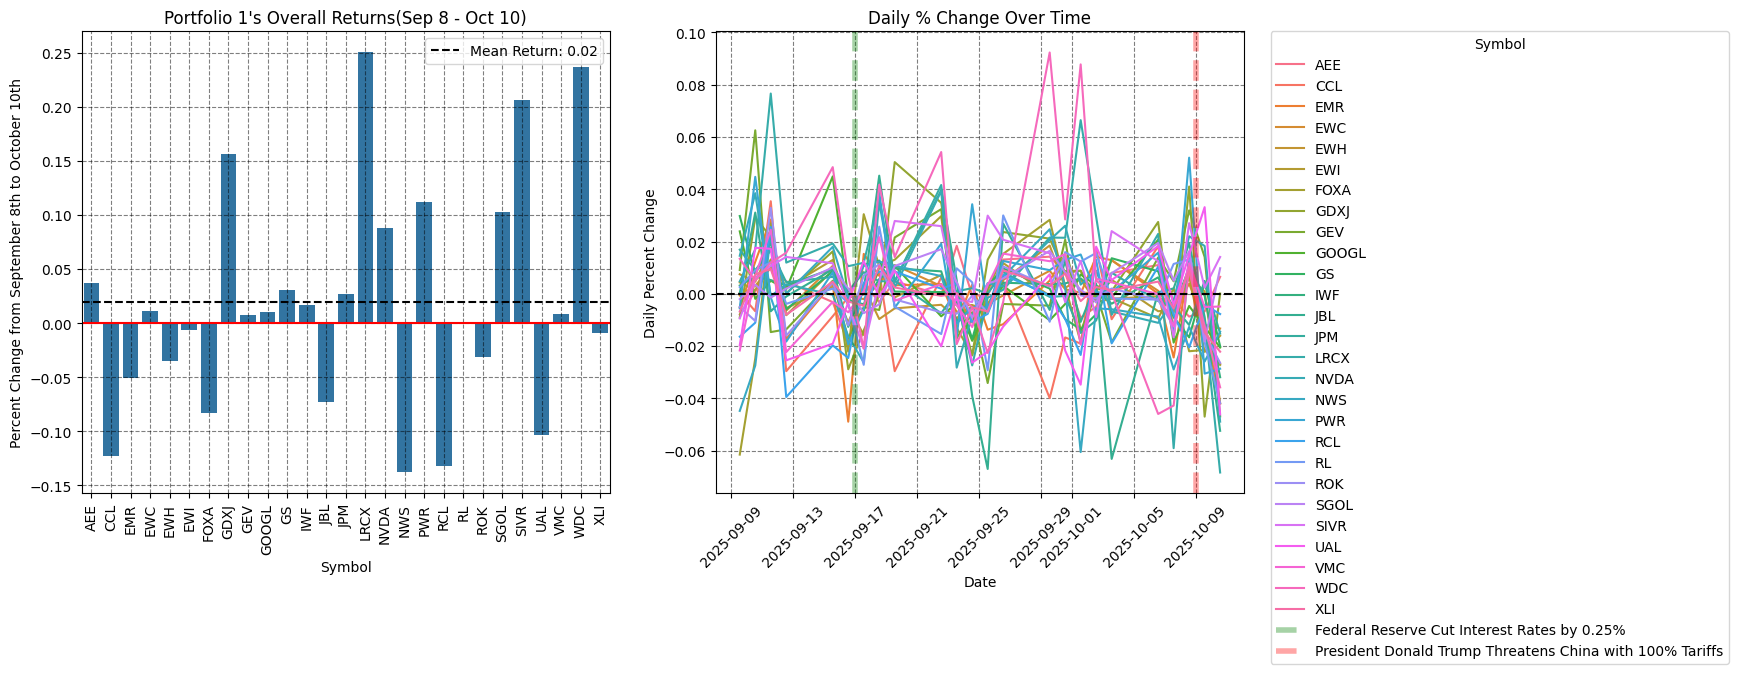

In [8]:
pct_changes = p1_prices.groupby('Symbol').apply(
    lambda x: (x['close'].iloc[-1] - x['close'].iloc[0]) / x['close'].iloc[0]
).reset_index(name='pct_change')

display(pct_changes.sort_values(by="pct_change"))

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(pct_changes, x="Symbol", y="pct_change", ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].grid(alpha = 0.5, linestyle = '--', color = 'k')
ax[0].axhline(y=pct_changes['pct_change'].mean(), label = f"Mean Return: {round(pct_changes['pct_change'].mean(), 2)}", linestyle='--', color='k')
ax[0].axhline(y=0, color='r')
ax[0].set_ylabel("Percent Change from September 8th to October 10th")
ax[0].set_title("Portfolio 1's Overall Returns(Sep 8 - Oct 10)")
ax[0].legend()

p1_prices_copy = p1_prices.sort_values(by=["Symbol", "timestamp"]).reset_index(drop=True)
sns.lineplot(data=p1_prices_copy, x="timestamp", y="pct_change", hue="Symbol", ax=ax[1])



ax[1].set_title("Daily % Change Over Time")
ax[1].set_ylabel("Daily Percent Change")
ax[1].set_xlabel("Date")
ax[1].grid(alpha=0.5, linestyle='--', color='k')
ax[1].tick_params(axis='x', rotation=45)
ax[1].axhline(y=0, linestyle='--', color='k')

ax[1].axvline(x=FED_CUT_DATE, color='g', linestyle='--', linewidth=4, alpha = 0.35, label="Federal Reserve Cut Interest Rates by 0.25%")
ax[1].axvline(x=TARRIF_DATE, color='r', linestyle='--', linewidth=4, alpha = 0.35, label="President Donald Trump Threatens China with 100% Tariffs")

ax[1].legend(
    title="Symbol",
    bbox_to_anchor=(1.05, 1),  
    loc='upper left',         
    borderaxespad=0.           
)



plt.show()

### Lets see how much money was made

In [9]:
merged_data = pd.merge(p1_amt, p1_prices[['Symbol', 'timestamp', 'close']], on='Symbol', how='left')
merged_data["amt"] = merged_data["n_shares"]*merged_data["close"]

merged_data

,Symbol,n_shares,timestamp,close,amt
0,GS,0.563220,2025-09-08 13:30:00,741.849976,417.824974
1,GS,0.563220,2025-09-09 13:30:00,763.919983,430.255250
2,GS,0.563220,2025-09-10 13:30:00,769.580017,433.443097
3,GS,0.563220,2025-09-11 13:30:00,784.729980,441.975864
4,GS,0.563220,2025-09-12 13:30:00,780.059998,439.345634
...,...,...,...,...,...
670,RL,1.306667,2025-10-06 13:30:00,321.100006,419.570689
671,RL,1.306667,2025-10-07 13:30:00,324.769989,424.366133
672,RL,1.306667,2025-10-08 13:30:00,329.029999,429.932546
673,RL,1.306667,2025-10-09 13:30:00,322.929993,421.961872


In [10]:
amt_earned = merged_data.groupby('Symbol').apply(
    lambda x: (x['amt'].iloc[-1] - x['amt'].iloc[0])
).reset_index(name='amt_earned')

amt_earned.sort_values(by = "amt_earned", ascending = False)

,Symbol,amt_earned
25,WDC,82.958803
7,GDXJ,78.644073
22,SIVR,74.387804
14,LRCX,63.273953
21,SGOL,60.202705
15,NVDA,30.397637
17,PWR,29.897634
10,GS,12.678095
13,JPM,11.996159
0,AEE,11.857948


In [11]:
tot = round(sum(amt_earned["amt_earned"]), 2)
print(f"Portfio 1 Earned: ${tot}")
print(f"Total Amout is: ${10000+tot}")
print(f"Total Return is: {round((((10000+tot)-10000)/10000)*100, 2)}%")

Portfio 1 Earned: $167.67
Total Amout is: $10167.67
Total Return is: 1.68%


## Portfolio #2. Portfolio created through identifying industry leaders(by sharpe ratio) 

In [12]:
p2 = pd.read_csv("sector_portolio.csv")
p2_amt = p2[["Symbol", "n_shares"]]

display(p2)
print(); print()
display(p2_amt.head())

,Symbol,Type,Monthly_Sharpe_Ratio,Annualized_Sharpe_Ration,Close,frac_inv,n_shares,invt_amount
0,TTWO,Communication Services,0.562152,1.947351,249.770004,0.071328,2.855739,713.277984
1,DASH,Consumer Discretionary,0.676501,2.343470,249.979996,0.085837,3.433749,858.368625
2,DLTR,Consumer Staples,0.455303,1.577215,98.709999,0.057770,5.852539,577.704110
3,EQT,Energy,0.395609,1.370431,51.139999,0.050196,9.815468,501.963009
4,HOOD,Financials,0.833824,2.888450,115.989998,0.105798,9.121345,1057.984828
5,GILD,Health Care,0.439778,1.523435,115.459999,0.055801,4.832889,558.005384
6,GEV,Industrials,0.655345,2.270180,602.530029,0.083152,1.380054,831.524166
7,PLTR,Information Technology,0.766555,2.655425,156.660004,0.097263,6.208554,972.632092
8,CTVA,Materials,0.312841,1.083713,72.300003,0.039694,5.490228,396.943514
9,WELL,Real Estate,0.387958,1.343927,168.675003,0.049226,2.918364,492.255033


,Symbol,n_shares
0,TTWO,2.855739
1,DASH,3.433749
2,DLTR,5.852539
3,EQT,9.815468
4,HOOD,9.121345


In [13]:
p2_tickers = p2.Symbol.tolist()

In [14]:
# Get data as before
p2_prices = pd.DataFrame()
start = time.time()
print("Loading...")

# Columns returned by .yahoo_api_price: timestamp, volume, close, open, high, low, currency, timezone, exchangeTimezoneName, exchangeName, instrumentType
for ticker in p2_tickers: 
    temp_tick = Ticker(ticker)
    security_df = temp_tick.yahoo_api_price(range='1y', dataGranularity='1d')
    security_df = security_df[["timestamp", "low", "high", "open", "close", "instrumentType"]]
    
    mask = (security_df["timestamp"].dt.date >= inv_start) & (security_df["timestamp"].dt.date <= inv_end)
    filtered_df = security_df[mask]
    
    # Use .loc[] to avoid SettingWithCopyWarning
    filtered_df.loc[:, "Symbol"] = ticker
    
    p2_prices = pd.concat([p2_prices, filtered_df])

end = time.time()
print("Loaded in ", end-start, " seconds")

Loading...
Loaded in  2.4113736152648926  seconds


In [15]:
p2_prices

,timestamp,low,high,open,close,instrumentType,Symbol
225,2025-09-08 13:30:00,241.399994,250.449997,241.779999,248.779999,EQUITY,TTWO
226,2025-09-09 13:30:00,247.270004,250.000000,249.279999,247.860001,EQUITY,TTWO
227,2025-09-10 13:30:00,243.460007,248.580002,248.580002,244.039993,EQUITY,TTWO
228,2025-09-11 13:30:00,244.889999,248.000000,246.070007,246.539993,EQUITY,TTWO
229,2025-09-12 13:30:00,244.029999,248.300003,245.970001,246.259995,EQUITY,TTWO
...,...,...,...,...,...,...,...
245,2025-10-06 13:30:00,100.900002,104.050003,101.169998,102.480003,ETF,GDXJ
246,2025-10-07 13:30:00,100.260002,102.610001,102.610001,100.680000,ETF,GDXJ
247,2025-10-08 13:30:00,102.220001,104.949997,103.110001,104.809998,ETF,GDXJ
248,2025-10-09 13:30:00,98.440002,105.239998,105.180000,99.889999,ETF,GDXJ


In [16]:
p2_prices["pct_change"] = p2_prices.groupby("Symbol")["close"].pct_change()
p2_prices["pct_change"]

225         NaN
226   -0.003698
227   -0.015412
228    0.010244
229   -0.001136
         ...   
245    0.027471
246   -0.017564
247    0.041021
248   -0.046942
249    0.000100
Name: pct_change, Length: 375, dtype: float64

,Symbol,pct_change
1,CTVA,-0.152433
3,DLTR,-0.118612
14,WELL,-0.020194
5,EWP,0.005409
7,GEV,0.007214
8,GILD,0.011219
13,TTWO,0.012823
10,IWF,0.016909
4,EQT,0.046493
0,CNP,0.051447


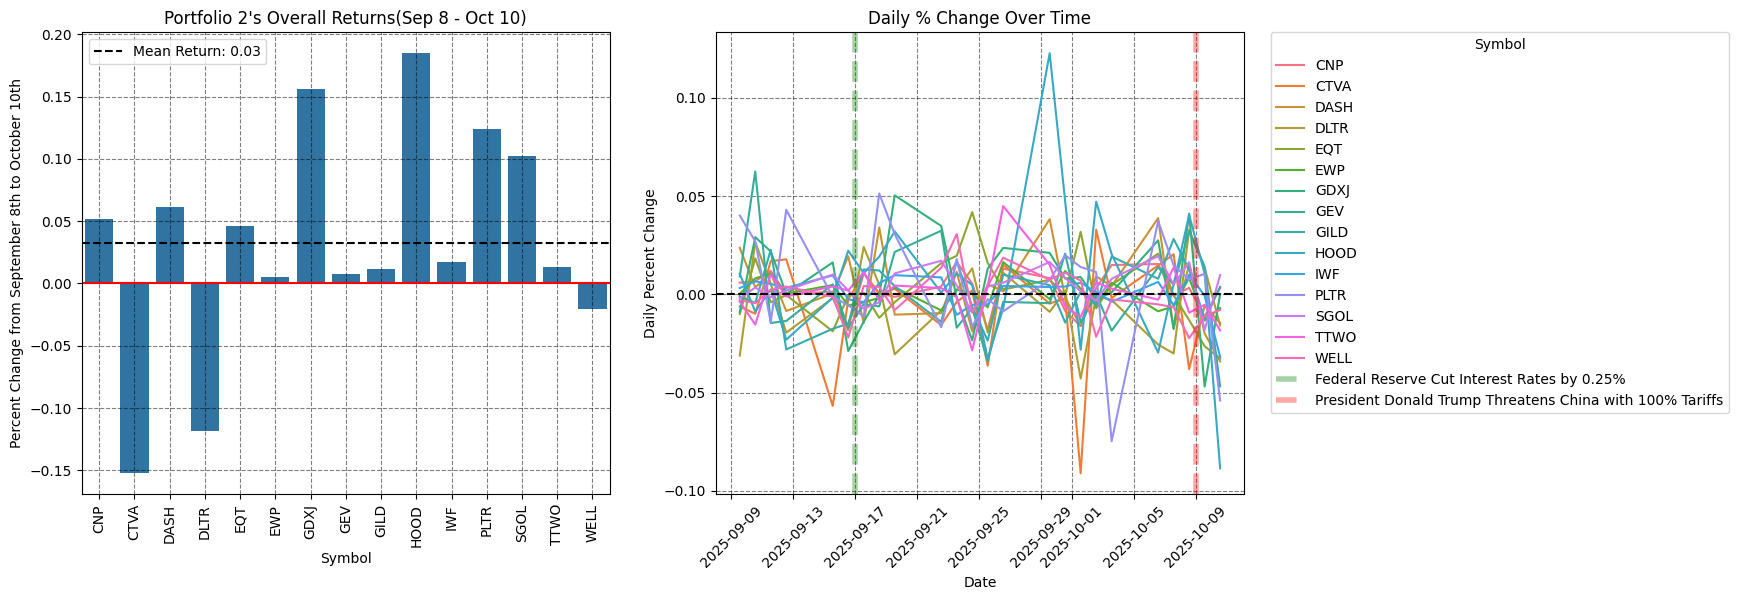

In [17]:
pct_changes = p2_prices.groupby('Symbol').apply(
    lambda x: (x['close'].iloc[-1] - x['close'].iloc[0]) / x['close'].iloc[0]
).reset_index(name='pct_change')

display(pct_changes.sort_values(by="pct_change"))

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(pct_changes, x="Symbol", y="pct_change", ax=ax[0])
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=90)
ax[0].grid(alpha = 0.5, linestyle = '--', color = 'k')
ax[0].axhline(y=pct_changes['pct_change'].mean(), label = f"Mean Return: {round(pct_changes['pct_change'].mean(), 2)}", linestyle='--', color='k')
ax[0].axhline(y=0, color='r')
ax[0].set_ylabel("Percent Change from September 8th to October 10th")
ax[0].set_title("Portfolio 2's Overall Returns(Sep 8 - Oct 10)")
ax[0].legend()

p2_prices_copy = p2_prices.sort_values(by=["Symbol", "timestamp"]).reset_index(drop=True)
sns.lineplot(data=p2_prices_copy, x="timestamp", y="pct_change", hue="Symbol", ax=ax[1])



ax[1].set_title("Daily % Change Over Time")
ax[1].set_ylabel("Daily Percent Change")
ax[1].set_xlabel("Date")
ax[1].grid(alpha=0.5, linestyle='--', color='k')
ax[1].tick_params(axis='x', rotation=45)
ax[1].axhline(y=0, linestyle='--', color='k')

ax[1].axvline(x=FED_CUT_DATE, color='g', linestyle='--', linewidth=4, alpha = 0.35, label="Federal Reserve Cut Interest Rates by 0.25%")
ax[1].axvline(x=TARRIF_DATE, color='r', linestyle='--', linewidth=4, alpha = 0.35, label="President Donald Trump Threatens China with 100% Tariffs")

ax[1].legend(
    title="Symbol",
    bbox_to_anchor=(1.05, 1),  
    loc='upper left',         
    borderaxespad=0.           
)



plt.show()

In [18]:
merged_data = pd.merge(p2_amt, p2_prices[['Symbol', 'timestamp', 'close']], on='Symbol', how='left')
merged_data["amt"] = merged_data["n_shares"]*merged_data["close"]

merged_data

,Symbol,n_shares,timestamp,close,amt
0,TTWO,2.855739,2025-09-08 13:30:00,248.779999,710.450786
1,TTWO,2.855739,2025-09-09 13:30:00,247.860001,707.823512
2,TTWO,2.855739,2025-09-10 13:30:00,244.039993,696.914567
3,TTWO,2.855739,2025-09-11 13:30:00,246.539993,704.053915
4,TTWO,2.855739,2025-09-12 13:30:00,246.259995,703.254312
...,...,...,...,...,...
370,GDXJ,7.154787,2025-10-06 13:30:00,102.480003,733.222621
371,GDXJ,7.154787,2025-10-07 13:30:00,100.680000,720.343982
372,GDXJ,7.154787,2025-10-08 13:30:00,104.809998,749.893233
373,GDXJ,7.154787,2025-10-09 13:30:00,99.889999,714.691693


In [20]:
amt_earned = merged_data.groupby('Symbol').apply(
    lambda x: (x['amt'].iloc[-1] - x['amt'].iloc[0])
).reset_index(name='amt_earned')

amt_earned.sort_values(by = "amt_earned", ascending = False)

,Symbol,amt_earned
9,HOOD,197.750840
11,PLTR,120.073412
6,GDXJ,96.732754
12,SGOL,74.049743
2,DASH,52.948355
0,CNP,37.291779
4,EQT,23.164510
13,TTWO,9.109815
8,GILD,6.282771
7,GEV,5.975659


In [21]:
tot = round(sum(amt_earned["amt_earned"]), 2)
print(f"Portfio 1 Earned: ${tot}")
print(f"Total Amout is: ${10000+tot}")
print(f"Total Return is: {round((((10000+tot)-10000)/10000)*100, 2)}%")

Portfio 1 Earned: $492.47
Total Amout is: $10492.47
Total Return is: 4.92%
